# ConvNeXtV2 Tiny From Scratch / Non-Pretrained

Purpose: collect the ConvNeXtV2 Tiny scratch runs in one notebook. These runs disable pretrained weights and train the full network on strict split manifests with early stopping.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

master_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.csv'
summary_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.json'
if not master_path.exists() or not summary_path.exists():
    display(Markdown("**Model results summary not found. Rebuilding from local metric artifacts...**"))
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)

master = pd.read_csv(master_path)
summary = json.loads(summary_path.read_text(encoding='utf-8'))

metric_cols = [
    'model_name', 'run_group', 'pretrained', 'seed', 'split',
    'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
    'best_epoch', 'epochs_trained', 'recommendation', 'notes'
]

loaded_rows = master[master['status'] == 'loaded'].copy()
missing_rows = master[master['status'] != 'loaded'].copy()
if missing_rows.empty:
    display(Markdown(f"**Artifact status:** all `{len(master)}` result rows loaded from local metrics."))
else:
    display(Markdown(
        f"**Artifact status:** `{len(loaded_rows)}` loaded, `{len(missing_rows)}` missing. "
        "Missing rows mean the ignored metric/checkpoint artifacts are not present locally. "
        "Run the reproduction commands in this notebook, then rerun `python -m src.evaluation.build_model_results_master`."
    ))
    display(missing_rows[['model_family', 'run_group', 'seed', 'status', 'metrics_file']].head(20))

def rebuild_master_results():
    """Rebuild reports/model_comparison from whatever metric artifacts exist locally."""
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)
    return pd.read_csv(master_path)

**Artifact status:** all `18` result rows loaded from local metrics.

In [2]:
def show_existing_figures(rows):
    for _, row in rows.iterrows():
        title = f"{row['run_group']} seed={row['seed']}"
        print(title)
        for column in ['confusion_matrix_figure', 'training_curve_figure']:
            value = row.get(column)
            if isinstance(value, str) and value:
                path = ROOT / value
                if path.exists():
                    display(Image(filename=str(path)))

In [3]:
convnext_scratch = master[(master['model_family'] == 'convnextv2_tiny') & (master['pretrained'] == False)].copy()
convnext_scratch[metric_cols].sort_values(['run_group', 'seed'])

,model_name,run_group,pretrained,seed,split,accuracy,precision_macro,recall_macro,f1_macro,best_epoch,epochs_trained,recommendation,notes
15,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,42.0,strict contiguous split seed 42,0.991071,0.991133,0.991071,0.991045,27.0,29.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...
16,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,123.0,strict contiguous split seed 123,0.957143,0.957790,0.957143,0.957109,22.0,32.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...
17,ConvNeXtV2 Tiny from scratch 50ep early-stoppe...,convnextv2_scratch_50ep_early_stopped_strict,False,999.0,strict contiguous split seed 999,0.978571,0.979279,0.978571,0.978561,12.0,22.0,scratch ConvNeXt comparison,50-epoch maximum scratch run with early stoppi...


In [4]:
convnext_scratch.groupby('run_group').agg(
    runs=('accuracy', 'count'),
    mean_accuracy=('accuracy', 'mean'),
    min_accuracy=('accuracy', 'min'),
    max_accuracy=('accuracy', 'max'),
    mean_f1=('f1_macro', 'mean'),
).reset_index()

,run_group,runs,mean_accuracy,min_accuracy,max_accuracy,mean_f1
0,convnextv2_scratch_50ep_early_stopped_strict,3,0.975595,0.957143,0.991071,0.975572


convnextv2_scratch_50ep_early_stopped_strict seed=42.0


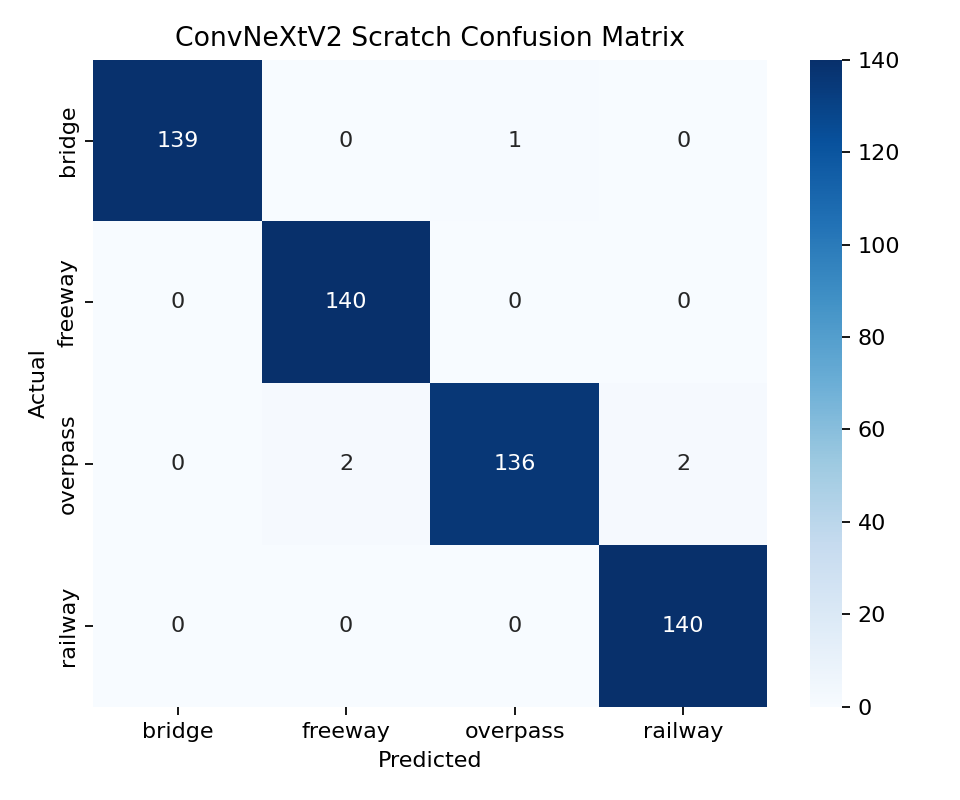

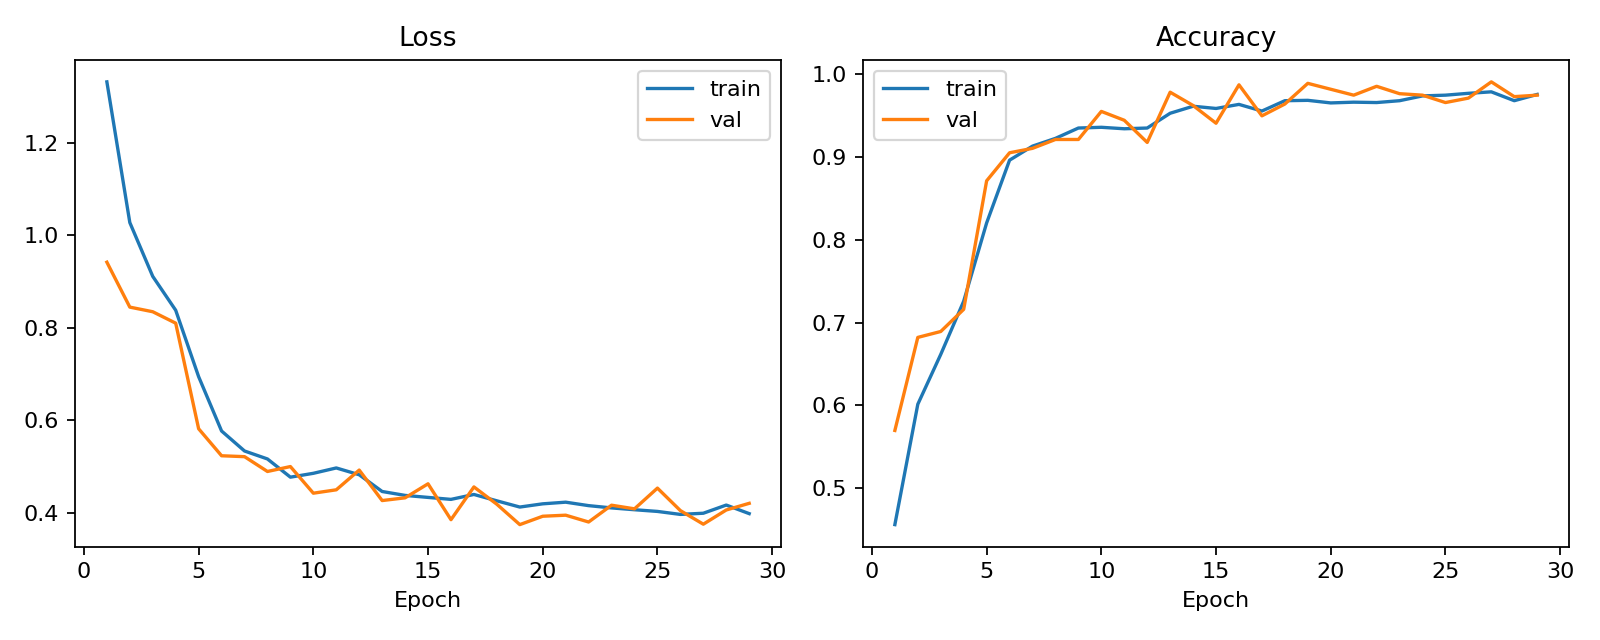

convnextv2_scratch_50ep_early_stopped_strict seed=123.0


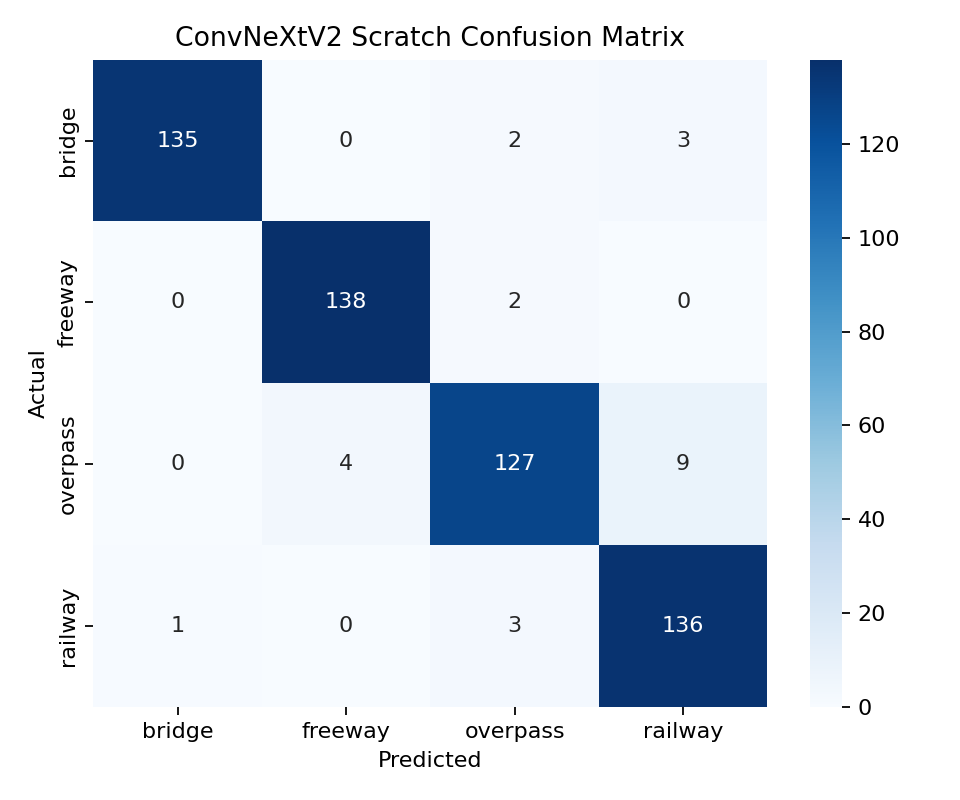

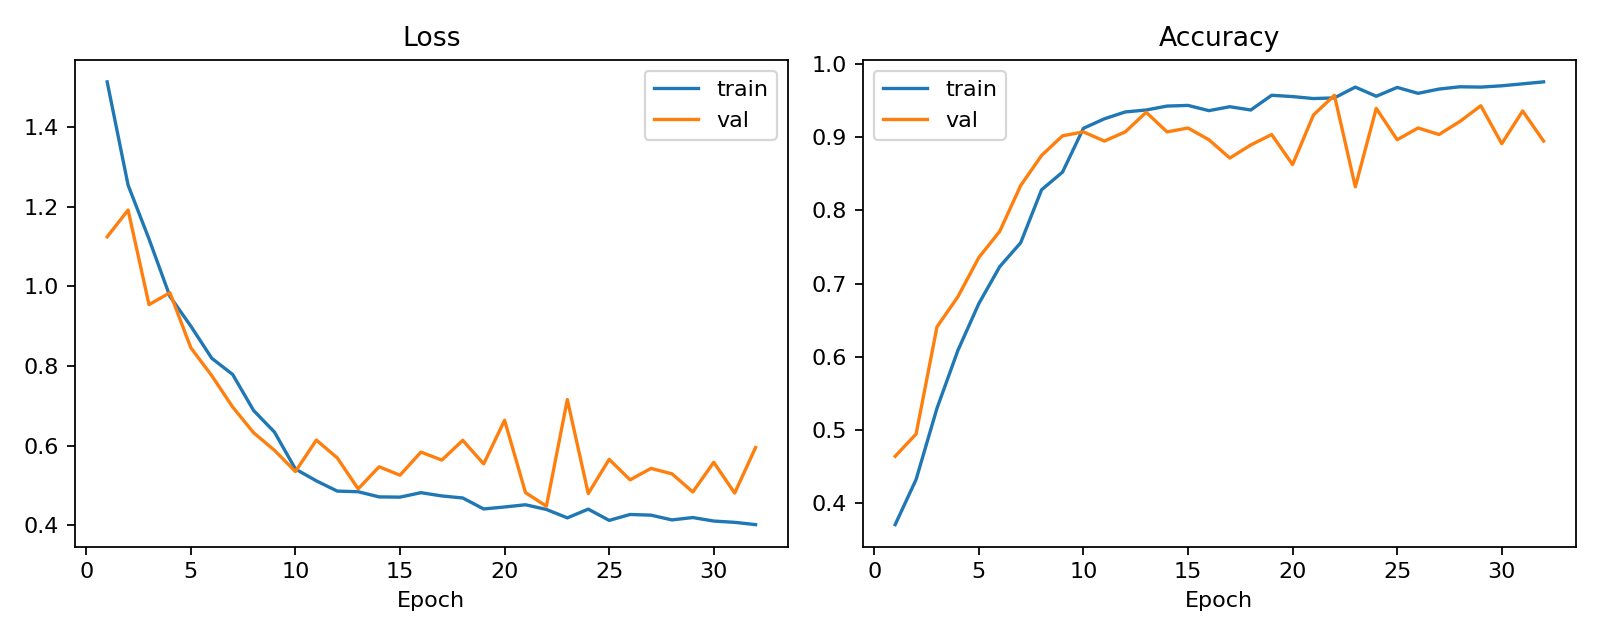

convnextv2_scratch_50ep_early_stopped_strict seed=999.0


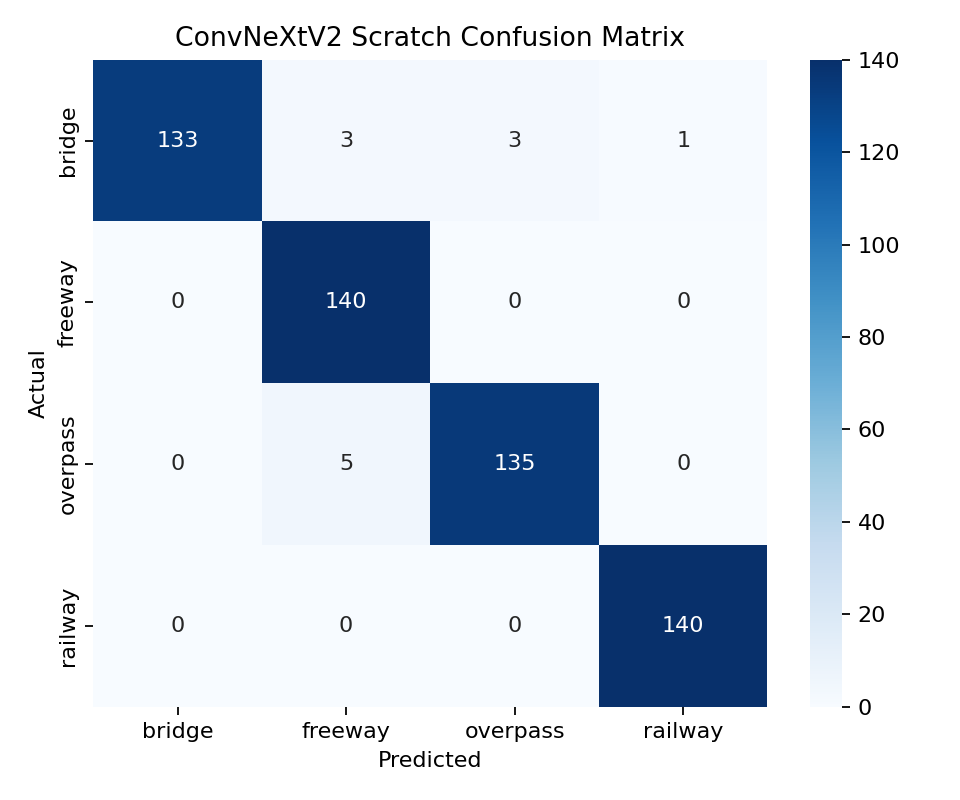

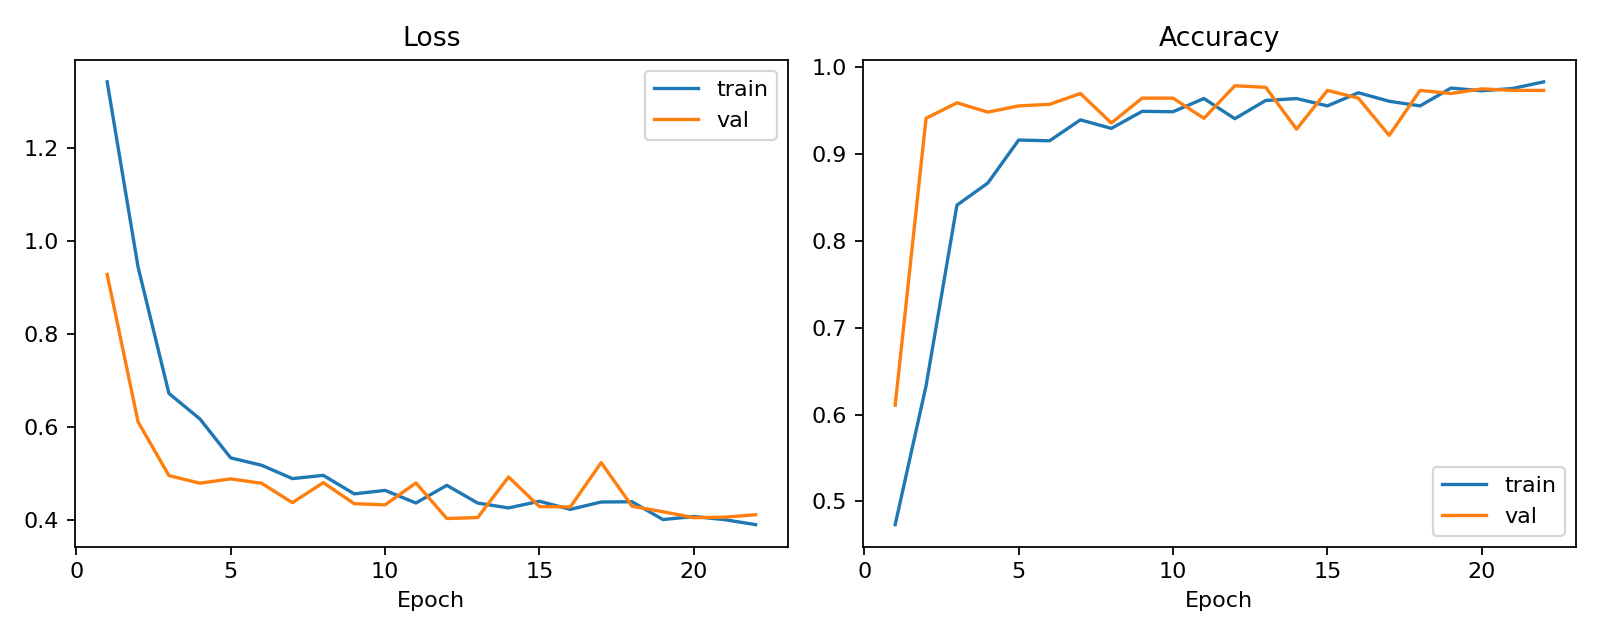

In [5]:
show_existing_figures(convnext_scratch)